# Assignment — Logistic Regression on `penguins.csv`

**Question:** given a penguin's measurements, is it male or female?

Target: `sex` &nbsp;·&nbsp; File: `penguins.csv`

Use only the numeric columns: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`,
`body_mass_g`.

**Keep this notebook.** Next class we will come back to the model you build here and
measure it properly.

In [236]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

df = pd.read_csv('/Users/alokkumardalei/Desktop/ml-assignment/Penguins/penguins.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


---
## 1. Look at the data

> **Flow:** Shape, columns, missing values.

Run `.info()`. Which columns have missing values, and how many?

In [237]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


How many male and how many female? Use `sns.countplot`.

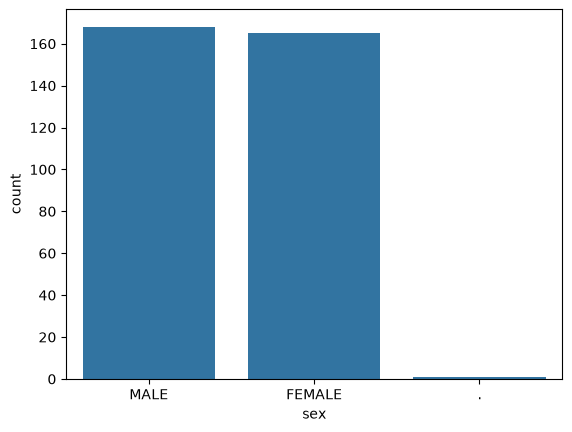

In [238]:


sns.countplot(data=df,x=df['sex'])
plt.show()


*Counts:* &nbsp;&nbsp; *Are the two classes roughly equal, or is one much bigger?*

Now compare the two groups on one measurement. Use `sns.barplot` with `x='sex'` and
`y='body_mass_g'`.

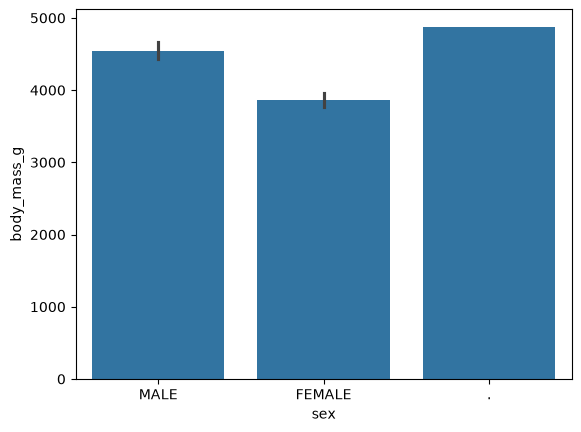

In [239]:
sns.barplot(data=df,x=df['sex'],y=df['body_mass_g'])
plt.show()

**Q.** Looking at that plot, does `body_mass_g` look useful for telling males and females
apart? One line.

---
## 2. Clean

> **Flow:** The target cannot be guessed. Rows missing it have to go.

`sex` is what we are trying to predict, so we cannot fill it in. Keep the four numeric
columns plus `sex`, then `dropna()`.

In [241]:
df=df.drop(columns=['species','island'])
df.head()
df.dropna(subset=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex'],inplace=True)
# Drop the sneaky NaN that got created from the "."
df.dropna(subset=['sex'], inplace=True)

# Convert the column to integers


df.head()

# df.info()
# df.head()

KeyError: "['species', 'island'] not found in axis"

*How many rows are left?*

The target is text — `Male` and `Female`. Map it to numbers:
`{'Female': 0, 'Male': 1}`.

In [242]:
# The text in the dataframe is fully capitalized
# 1. Map the text values to numbers
mapping = {'FEMALE': 0, 'MALE': 1}
df['sex'] = df['sex'].map(mapping)

# 2. Drop the sneaky NaN that got created from the "."
df.dropna(subset=['sex'], inplace=True)

# 3. Convert the column to integers
df['sex'] = df['sex'].astype('int64')

df.head()



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,1


---
## 3. Features and target

In [243]:
x=df.drop(columns=['sex'])
y=df['sex']

---
## 4. Split

> **Flow:** `test_size=0.2`, `random_state=42`, `stratify=y`.

In [244]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

**Q.** Why do we use `stratify=y` here? One line.

---
## 5. Train the model

> **Flow:** Two lines, same as always.

Train `LogisticRegression(max_iter=1000)` and predict on the test set.

In [250]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,r2_score

model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
y_pre=model.predict(x_test)



**Q.** What does `max_iter=1000` do? One line.

---
## 6. Accuracy

In [251]:
print(accuracy_score(y_pre,y_test))
print(r2_score(y_pre,y_test))

0.8656716417910447
0.45675675675675687
